# Resumo da EDA

* **Estrutura da base:** O dataset possui 1460 registros e 81 variáveis, sendo 43 categóricas, 35 inteiras e 3 numéricas contínuas.

* **Valores ausentes:** Algumas colunas possuem muitos valores nulos, como `PoolQC`, `MiscFeature`, `Alley`, `Fence`, `FireplaceQu`, `LotFrontage` e `MasVnrType`. Em parte dessas variáveis, os nulos provavelmente representam ausência da característica.

* **Variável alvo:** `SalePrice` apresenta distribuição assimétrica à direita, com concentração de imóveis em valores mais baixos e alguns imóveis muito caros.

* **Correlação com o preço:** As variáveis mais associadas ao `SalePrice` parecem ser `OverallQual`, `GrLivArea`, `GarageCars`, `GarageArea`, `TotalBsmtSF`, `1stFlrSF`, `FullBath`, `YearBuilt` e `YearRemodAdd`.

* **Multicolinearidade:** Algumas variáveis explicativas apresentam forte correlação entre si, como `GarageCars` e `GarageArea`, além de variáveis relacionadas à área construída.

* **Distribuições assimétricas:** Muitas variáveis numéricas possuem assimetria à direita, como `LotArea`, `MasVnrArea`, `BsmtFinSF1`, `GrLivArea`, `WoodDeckSF`, `OpenPorchSF`, `PoolArea` e `MiscVal`.

* **Outliers:** Os boxplots indicam presença de outliers principalmente em variáveis de área, garagem, porão, varanda e preço de venda.

* **Próximos passos:** Tratar valores ausentes, avaliar outliers, transformar variáveis muito assimétricas e codificar variáveis categóricas antes da modelagem.


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [4]:
df = pd.read_csv(r"..\data\raw\house_price.csv")

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [10]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [9]:
df.nunique().sort_index(ascending=False)

YrSold            5
YearRemodAdd     61
YearBuilt       112
WoodDeckSF      274
Utilities         2
               ... 
BedroomAbvGr      8
Alley             2
3SsnPorch        20
2ndFlrSF        417
1stFlrSF        753
Length: 81, dtype: int64

In [11]:
df.skew(numeric_only=True)

Id                0.000000
MSSubClass        1.407657
LotFrontage       2.163569
LotArea          12.207688
OverallQual       0.216944
OverallCond       0.693067
YearBuilt        -0.613461
YearRemodAdd     -0.503562
MasVnrArea        2.669084
BsmtFinSF1        1.685503
BsmtFinSF2        4.255261
BsmtUnfSF         0.920268
TotalBsmtSF       1.524255
1stFlrSF          1.376757
2ndFlrSF          0.813030
LowQualFinSF      9.011341
GrLivArea         1.366560
BsmtFullBath      0.596067
BsmtHalfBath      4.103403
FullBath          0.036562
HalfBath          0.675897
BedroomAbvGr      0.211790
KitchenAbvGr      4.488397
TotRmsAbvGrd      0.676341
Fireplaces        0.649565
GarageYrBlt      -0.649415
GarageCars       -0.342549
GarageArea        0.179981
WoodDeckSF        1.541376
OpenPorchSF       2.364342
EnclosedPorch     3.089872
3SsnPorch        10.304342
ScreenPorch       4.122214
PoolArea         14.828374
MiscVal          24.476794
MoSold            0.212053
YrSold            0.096269
S

In [12]:
df.dtypes.value_counts()

str        43
int64      35
float64     3
Name: count, dtype: int64

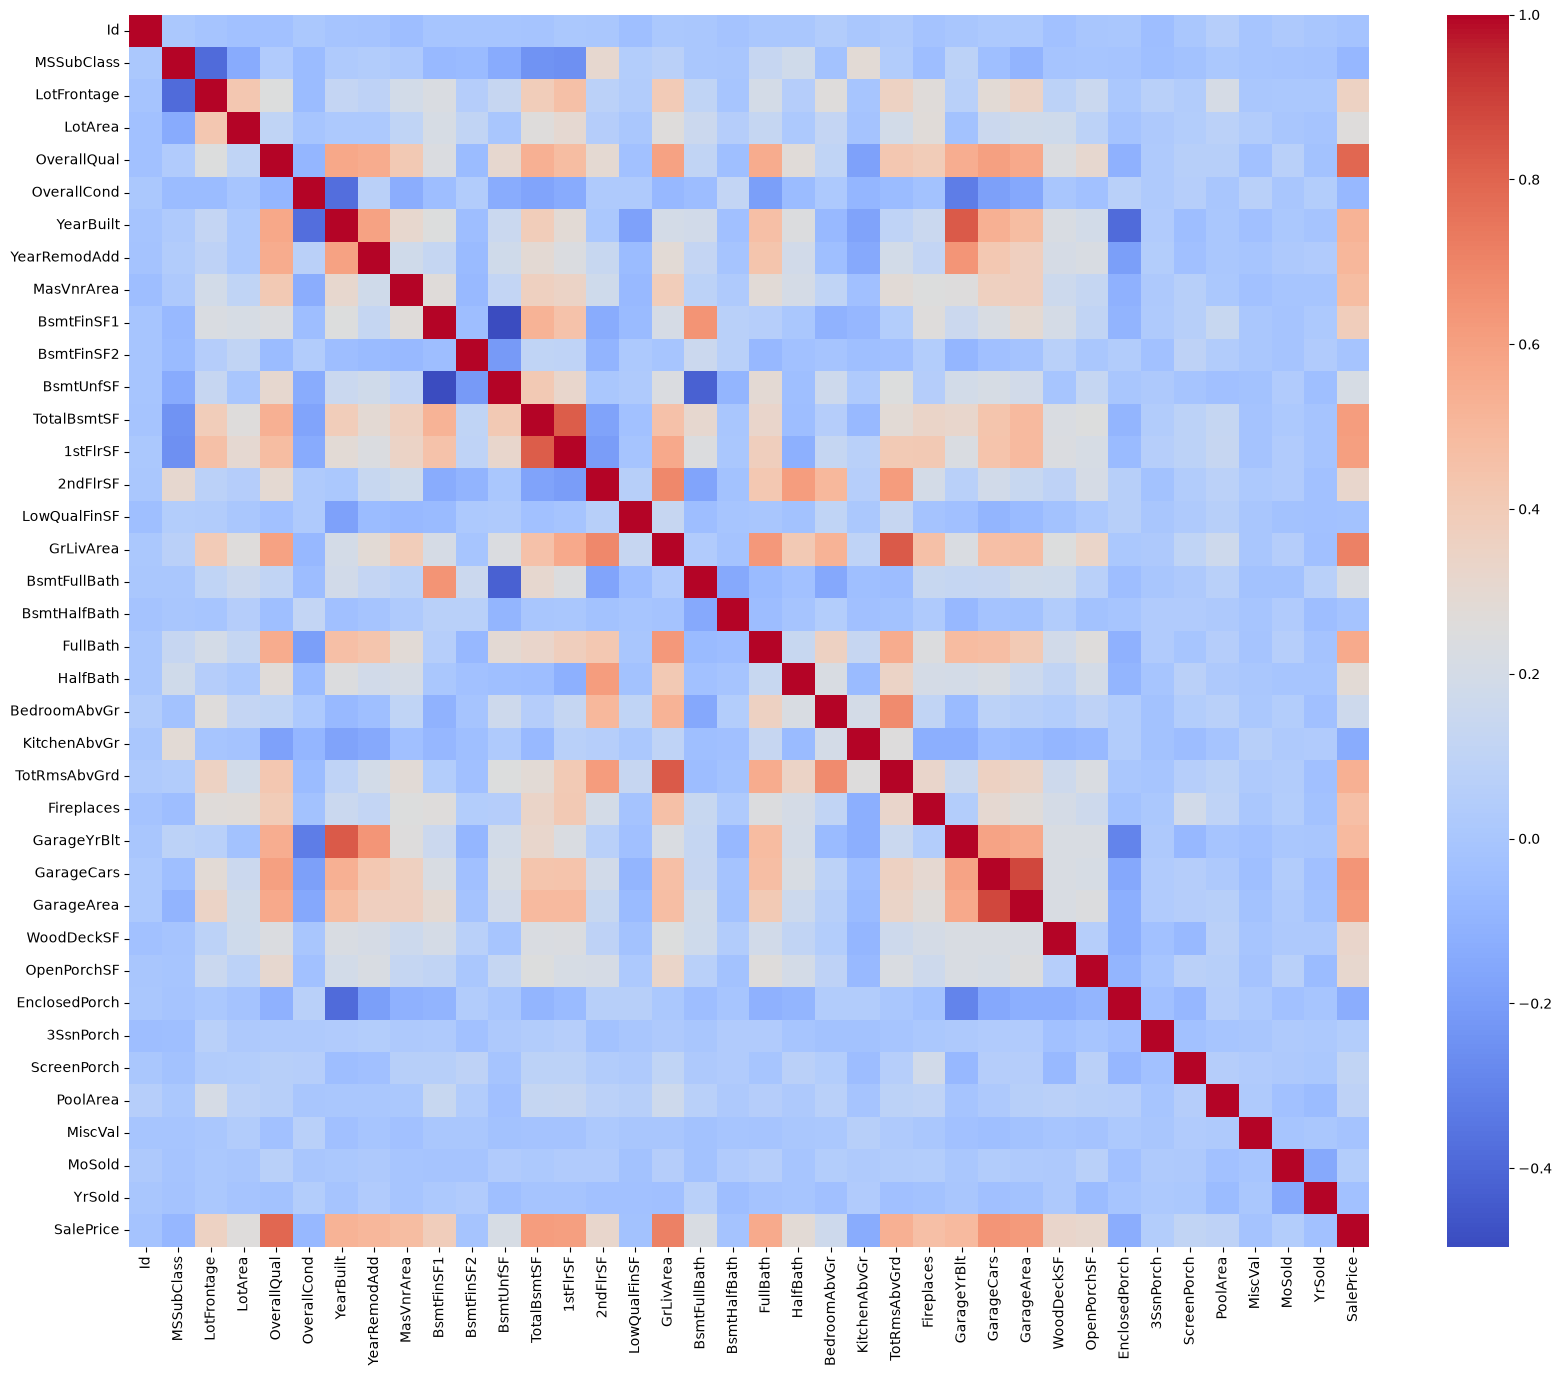

In [13]:
plt.figure(figsize=(20, 16))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.show()

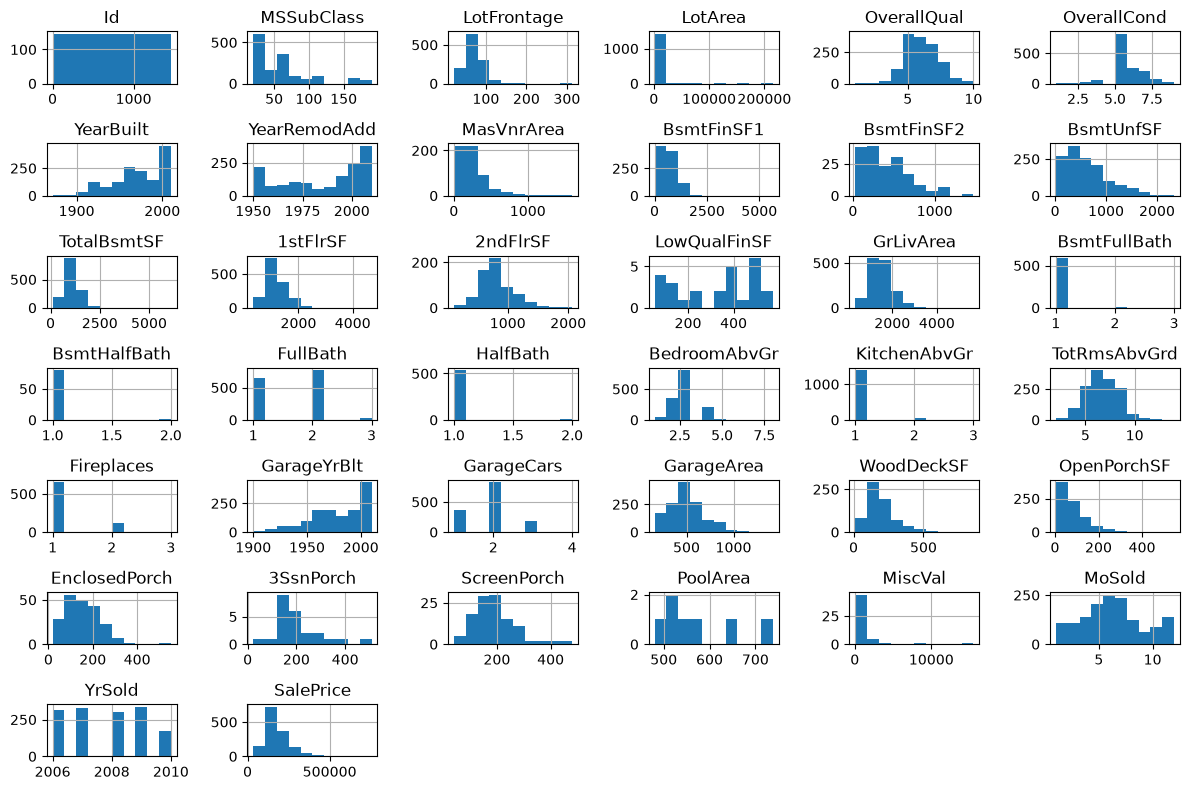

In [16]:
numericas = df.select_dtypes(include="number")

numericas.replace(0, np.nan).hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

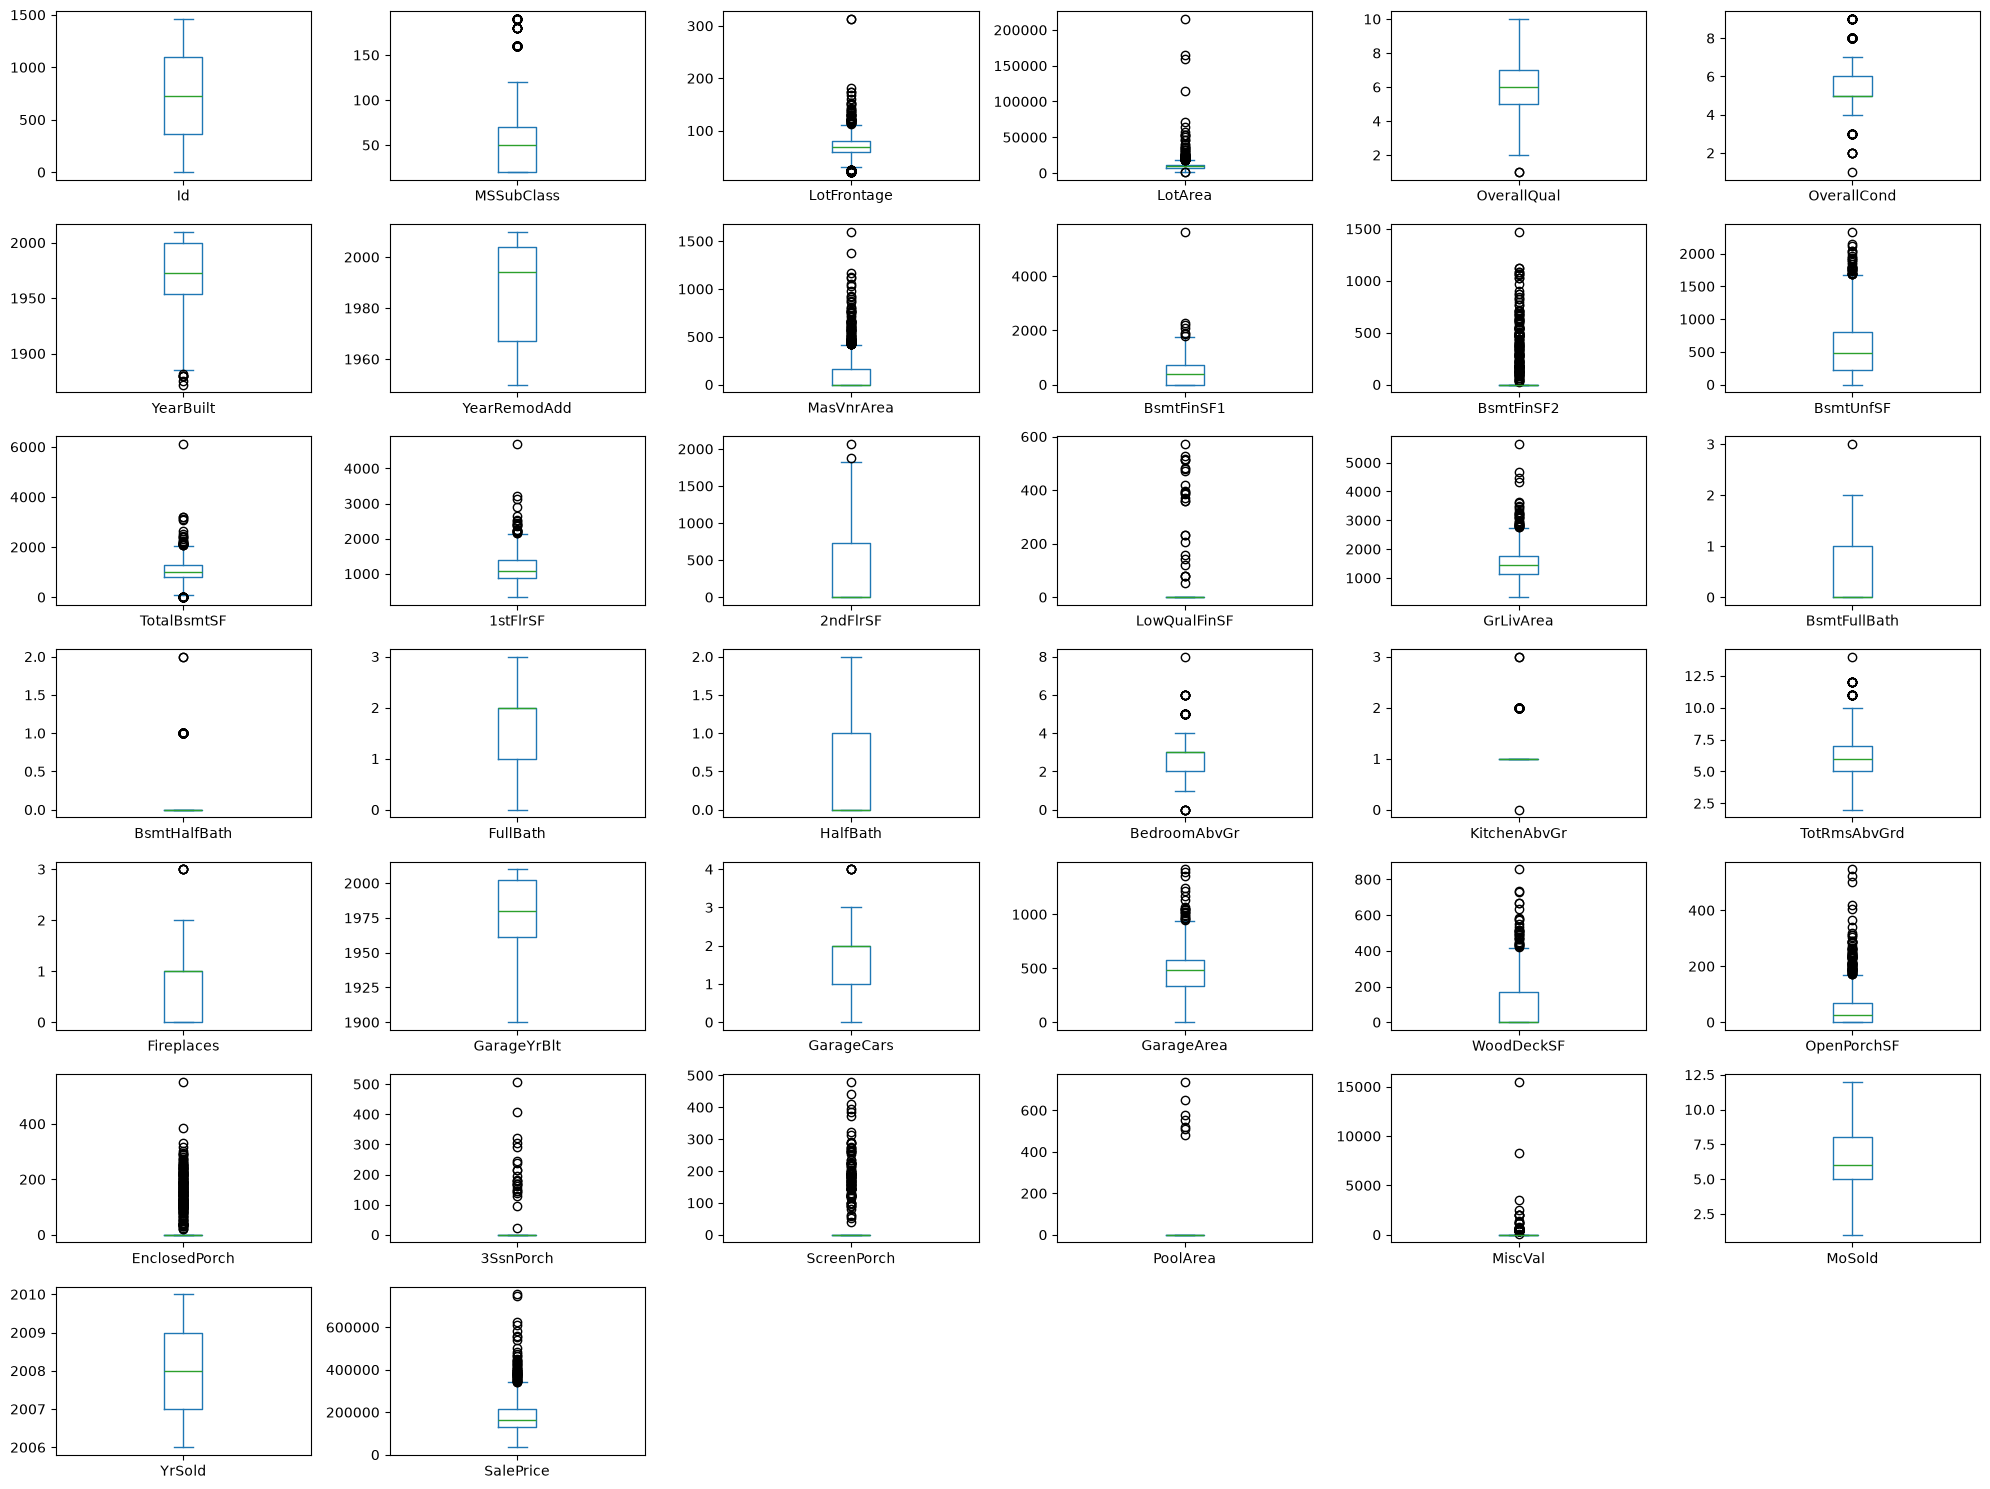

In [17]:
df.plot(
    kind='box',
    subplots=True,
    layout=(-1, 6),
    figsize=(20, 15),
    sharex=False,
    sharey=False
)

plt.tight_layout()
plt.show()